# 1D Fermi-Hubbard Dynamics with Majorana Propagation

In the following we will be studying real-time dynamics of interacting fermions in a classical Heisenberg-picture algorithm. This notebook is based on the research of D'Anna *et. al.*, such that we will try to reproduce their results and then apply the logic to our Kagome lattice, similar to what we did in 'kagomespd.ipynb'.[1]\
Majorana Propagation (MP) is the fermionic equivalent of Sparse Pauli Dynamics, with the twist that it operates in the **Majorana-string basis**, where fermionic operators are expanded as sums of Majorana operators. \
\
**A brief introduction into Majorana basis and MP:** \
For a detailed introduction into this topic, it would be appropriate to consider going through the referred to work or some other suitable literature.\
Instead of mapping fermionic operators to Pauli strings as for the Jordan-Wigner transformation, now we will be mapping those fermionic operators to products of Majorana operators. Majorana operators themselves are defined through fermionic operators as 
$$ c_j = a_j^{\dagger} + a_j, \quad \tilde{c_j} = i(a_j^{\dagger} - a_j)$$
where they obey the anticommutation relations 
$$\left\{c_i, c_j \right\} = \left\{\tilde{c_i}, \tilde{c_j} \right\} = 2\delta_{ij}, \qquad \left\{\tilde{c_i}, c_j \right\} = 0.$$
The self-adjoint $(c_i = \tilde{c_i})$ Majorana operators are then used to construct hermitian Majorana strings, represented by the binary vector $v = \left\{0,1\right\}^{2N}$ as 
$$\Gamma \equiv (i)^{v^T \omega_L v} \cdot c_1^{v_1}\tilde{c_1}^{v_2}  \cdots c_N^{v_{2N-1}}\tilde{c_N}^{v_{2N}},$$
while the phase factor $(i)^{v^T \omega_L v} = \left\{i,1\right\}$ recovers hermiticity of $ \Gamma = \Gamma^\dagger$, where $(\omega_L)_{ij} \equiv \delta_{i<j}$ is a $2N \times 2N$ lower triangular matrix. The matrix multiplication in the exponent is to be understood as mod 2.\
Another notable definition are unpaired Majorana strings. A mode $i$ is defined to be unpaired if it contains the operator $c_i$ without $\tilde{c_i}$ or vice versa. \
The number operator $n_i$ is defined as $$n_i = a_i^\dagger a_i = \frac{1}{2}(1+ic_i\tilde{c_i}).$$\
and the hopping operators as $$a_i^\dagger a_j + a_j^\dagger a_i = \frac{1}{2}(ic_i\tilde{c_j} - ic_i\tilde{c_j}), \qquad i < j.$$\
Majorna strings are closed under multiplication $$\mu(v)\,\mu(v') = \zeta\cdot \mu(v+v'), \qquad \zeta\in\{\pm1,\pm i\}$$ where $v + v^\prime$ is the bitwise addition mod 2.\
An important property is that these strings do satisfy the anticommuation relation $$\Gamma \Gamma^\prime = (-1)^{v^T \omega_L v^\prime} \Gamma^\prime \Gamma.$$



In [ ]:
try:
    from spd.SparsePauliDynamics import *
    from spd.BaseOperatorRepresentation import * 
except ImportError:
    print("\n" + "="*60)
    print("REQUIRED PACKAGE 'spd' NOT FOUND")
    print("="*60)
    print("This notebook relies on the 'spd' package.")
    print("Please install it before proceeding:\n")
    print("   pip install git+https://github.com/tbegusic/spd.git")
    print("="*60 + "\n")
    raise

import numpy as np
import matplotlib.pyplot as plt
from qiskit_nature.second_q.operators import FermionicOp

We consider a 1D chain of 4 spinful sites, where we will be simulating the dynamics of an inital Néel eigenstate (no hoppings, only singly occupied sites) at $U/t = +\infty$ evolving under the quenched Fermi-Hubbard Hamiltonian $$H = -t \sum_{\langle i,j\rangle,\sigma\in\{\uparrow,\downarrow\}} \left(c_{i,\sigma}^\dagger c_{j,\sigma} + c_{j,\sigma}^\dagger c_{i,\sigma}\right) + U \sum_i n_{i\uparrow} n_{i\downarrow} = H_{hop} + H_{rep}$$ with $U/t = 1$ in first order Trotter expansion. 

In [ ]:
L = 4                   
t = 1.0
U = 1.0
dt = 0.12   #Trotter time step                  
T = 6.0     # total simulation time                    
nsteps = int(T / dt) #number of Trotter steps   

threshold = 1e-5 # threshold for coefficient truncation

nmodes = 2 * L # total fermionic modes (spin up and down)

nlist = [(i, i+1) for i in range(L-1)] #list of nearest-neighbour pairs 

First, we initialize the hopping and on-site repulsion terms as an empty $\texttt{FermionicOp}$ object where terms will be added to gradually.\
Then we iterate over all nearest-neighbor bonds and define even indices as spin up and odd indices as spin down. Spin-up and spin-down hopping terms will be added in both directions while '+_{up_i} -_{up_j}' is the creation operaotr on site up_i and annihilation operator on site up_j. \
At this point the hopping part of the Hamiltonian is: $$H_{hop} = -t \sum_{\langle i,j\rangle} \left(c_{i,\uparrow}^\dagger c_{j,\uparrow} + c_{j,\uparrow}^\dagger c_{i,\uparrow} + c_{i,\downarrow}^\dagger c_{j,\downarrow} + c_{j,\downarrow}^\dagger c_{i,\downarrow}\right).$$
Now the on-site repulsion terms will be added similarly to the Hamiltonian by iterating over all sites, defining up and down index and compute the number operators for up- and down-spin. \
The repulsion part of the Hamiltonian is now: $$H_{rep} = U \sum_{i} n_{i, \uparrow} n_{i, \downarrow}.$$




In [ ]:
ham_hop = FermionicOp({}, nmodes) 
ham_rep = FermionicOp({}, nmodes) 


for i, j in nlist:
    up_i = 2 * i
    up_j = 2 * j
    ham_hop += FermionicOp({f'+_{up_i} -_{up_j}': -t}, num_spin_orbitals=nmodes)
    ham_hop += FermionicOp({f'+_{up_j} -_{up_i}': -t}, num_spin_orbitals=nmodes)
    down_i = 2 * i + 1
    down_j = 2 * j + 1
    ham_hop += FermionicOp({f'+_{down_i} -_{down_j}': -t}, num_spin_orbitals=nmodes)
    ham_hop += FermionicOp({f'+_{down_j} -_{down_i}': -t}, num_spin_orbitals=nmodes)

for site in range(L):
    up_idx = 2 * site
    down_idx = 2 * site + 1
    n_up = FermionicOp({f'+_{up_idx} -_{up_idx}': 1}, num_spin_orbitals=nmodes)
    n_down = FermionicOp({f'+_{down_idx} -_{down_idx}': 1}, num_spin_orbitals=nmodes)
    ham_rep += U * n_up @ n_down

After defining the observable on the central site as the number operator $n_{5,\uparrow}$, we will then go on to represent it using using Majorana operators (to enable the unpaired-Majorana truncation later on).\
Hopping and repulsion terms of the Hamiltonian are then represented as Pauli strings using Jordan-Wigner transormation (since the Hamiltonian will not be truncated, its terms will become the Pauli rotation gates that will drive the time evolution.)\
We will then multiply each part of the Hamiltonian by the time step $\Delta t$ producing Pauli rotation gates that approximate a first-order Trotter step as: $$e^{-iH\Delta t} \approx \prod_{j} e^{-ic_j\Delta t H_j}$$ where $H_j$ are Pauli operators. 

In [ ]:
central = 2  #central site index           
obs_up_idx = 2 * central #spin-up index for the central site
obs_ferm = FermionicOp({f'+_{obs_up_idx} -_{obs_up_idx}': 1}, num_spin_orbitals=nmodes)
obs_majorana = MajoranaRepresentation.from_fermionic_op(obs_ferm)

h_hop_majorana = MajoranaRepresentation.fermionic_to_sparse_pauli_op(ham_hop)
h_rep_majorana = MajoranaRepresentation.fermionic_to_sparse_pauli_op(ham_rep)

op = (dt * h_hop_majorana) + (dt * h_rep_majorana)

Then we will define the initial Néel state (antiferromagnetic state) with alternating up- and down-spins on odd and even sites: $$|\downarrow\, \uparrow\, \downarrow \,\uparrow \, \downarrow \,\uparrow  \, \downarrow \,\uparrow  \, \downarrow \,\uparrow \dots \rangle $$  

In [ ]:
state = np.zeros(nmodes, dtype=int)
for site in range(L):
    if site % 2 == 0:
        state[2*site+1] = 1 #even gets spin down
    else:
        state[2*site] = 1  #odd gets spin up

Here we compute the expectation value of the time-evolved observable with respect to the inital state. \
The function $\texttt{process}$ effectively computes the expectation value $$\langle \downarrow \uparrow \downarrow \uparrow | n_{5,\uparrow} | \downarrow \uparrow \downarrow \uparrow \rangle.$$ \
Then the mentioned truncation is applied by discarding all unpaired Majorana strings with more unpaired strings than the defined value. \
Then a $\texttt{Simulation}$ object is created while also truncating with respect to the before defined threshold. The simulation is then run while calling the $\texttt{process}$ function in total 6 times. 

In [ ]:
S = 4                     # unpaired Majorana cutoff

def process(obs_rep):
    """Compute expectation value and apply S truncation."""
    exp_val = MajoranaRepresentation.exp_val_comp_basis_state(obs_rep, state)

    # Discard strings with more than S unpaired Majoranas
    trunc = obs_rep.nonp_count <= S
    obs_rep.bits = obs_rep.bits[trunc]
    obs_rep.coeffs = obs_rep.coeffs[trunc]

    return exp_val

sim = Simulation(obs_majorana.copy(), op, threshold=threshold)
r = sim.run_dynamics(nsteps, process=process, process_every=1)

results = np.array(r)


In [ ]:
plt.plot(np.arange(len(results))*dt, results)
plt.show()

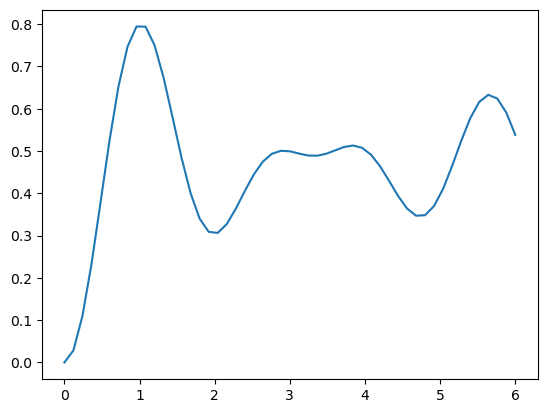

## References 

[1] D’Anna, Matteo, Jannes Nys, and Juan Carrasquilla. “Majorana String Simulation of Nonequilibrium Dynamics in Two-Dimensional Lattice Fermion Systems.” arXiv:2511.02809. Preprint, arXiv, November 4, 2025. https://doi.org/10.48550/arXiv.2511.02809.
